In [14]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import drive, files

print("Libraries imported successfully!")

Libraries imported successfully!


In [16]:
# Updated file path including the subfolder

# Load the CICMalDroid 2020 dataset

file_path = "/content/drive/MyDrive/Malicious_Mobile_Application_Detection/feature_vectors_syscallsbinders_frequency_5_Cat.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 11598
Number of columns: 471


In [17]:
# Display the first 5 rows
df.head()

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,0,37,10,1
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,0,2,2838,46,1
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,0,1,111,20,1
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,0,7,987,197,1
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,0,1,98,25,1


In [18]:
# Display all column names
print("Total columns:", len(df.columns))

for i, column in enumerate(df.columns):
    print(i, ":", column)

Total columns: 471
0 : ACCESS_PERSONAL_INFO___
1 : ALTER_PHONE_STATE___
2 : ANTI_DEBUG_____
3 : CREATE_FOLDER_____
4 : CREATE_PROCESS`_____
5 : CREATE_THREAD_____
6 : DEVICE_ACCESS_____
7 : EXECUTE_____
8 : FS_ACCESS____
9 : FS_ACCESS()____
10 : FS_ACCESS(CREATE)____
11 : FS_ACCESS(CREATE__APPEND)__
12 : FS_ACCESS(CREATE__READ)__
13 : FS_ACCESS(CREATE__READ__WRITE)
14 : FS_ACCESS(CREATE__WRITE)__
15 : FS_ACCESS(CREATE__WRITE__APPEND)
16 : FS_ACCESS(READ)____
17 : FS_ACCESS(READ__WRITE)__
18 : FS_ACCESS(WRITE)____
19 : FS_PIPE_ACCESS___
20 : FS_PIPE_ACCESS()___
21 : FS_PIPE_ACCESS(READ)___
22 : FS_PIPE_ACCESS(READ__)_
23 : FS_PIPE_ACCESS(READ__WRITE)_
24 : FS_PIPE_ACCESS(WRITE)___
25 : NETWORK_ACCESS____
26 : NETWORK_ACCESS()____
27 : NETWORK_ACCESS(READ)____
28 : NETWORK_ACCESS(READ__WRITE)__
29 : NETWORK_ACCESS(READ__WRITE__)
30 : NETWORK_ACCESS(WRITE)____
31 : NETWORK_ACCESS(WRITE__)__
32 : SMS_SEND____
33 : TERMINATE_PROCESS
34 : TERMINATE_THREAD
35 : __arm_nr_cacheflush
36 : __arm_

In [19]:
# Check the target/class column
print(df["Class"].value_counts())

Class
3    3904
4    2546
2    2100
5    1795
1    1253
Name: count, dtype: int64


In [20]:
# Map the numerical class labels to their actual categories

class_mapping = {
    1: "Adware",
    2: "Banking",
    3: "SMS Malware",
    4: "Riskware",
    5: "Benign"
}

df["Class_Name"] = df["Class"].map(class_mapping)

print(df["Class_Name"].value_counts())

Class_Name
SMS Malware    3904
Riskware       2546
Banking        2100
Benign         1795
Adware         1253
Name: count, dtype: int64


In [21]:
# Check for missing values

missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

print("\nColumns containing missing values:")
print(missing_values[missing_values > 0])

Total missing values: 0

Columns containing missing values:
Series([], dtype: int64)


In [22]:
# Check for duplicate rows

duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 72


In [23]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Duplicates removed successfully!")
print("New number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Duplicates removed successfully!
New number of rows: 11526
Number of columns: 472


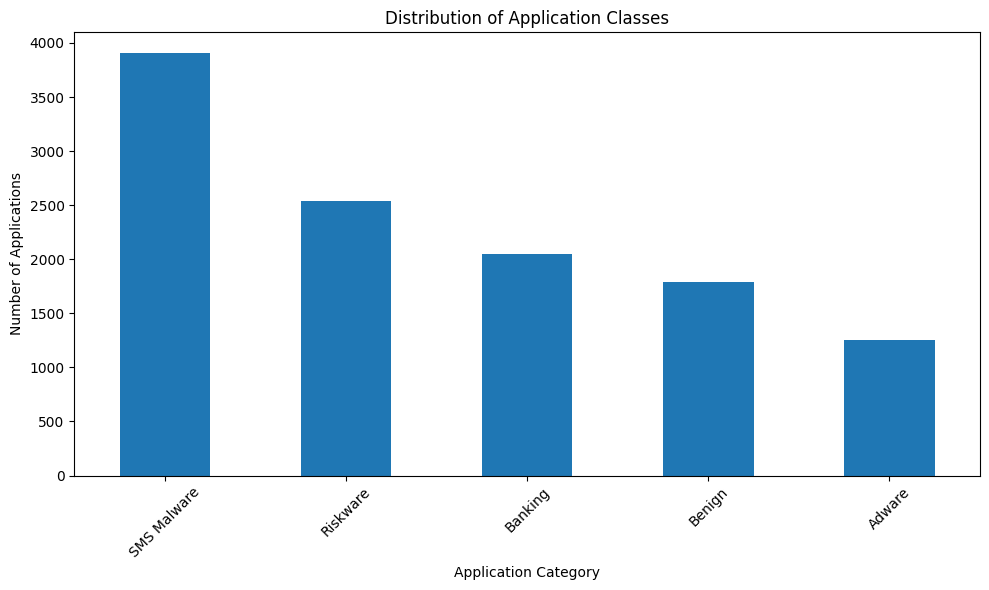

In [24]:
# Visualize the distribution of application classes

plt.figure(figsize=(10, 6))

df["Class_Name"].value_counts().plot(kind="bar")

plt.title("Distribution of Application Classes")
plt.xlabel("Application Category")
plt.ylabel("Number of Applications")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [25]:
# Statistical summary of the numerical features

print("Statistical Summary of the Dataset:")
display(df.describe())

Statistical Summary of the Dataset:


,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class
count,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,...,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,1.152600e+04,11526.000000
mean,57.790908,0.001215,0.044855,5.817283,0.990023,29.929724,29.820319,2.265053,74.103332,6.730175,...,0.093875,2.243797,0.001822,0.000694,6.491845,0.000694,1.658164,1077.795332,1.046051e+03,3.136040
std,445.511577,0.055876,1.107725,10.403308,4.073808,32.205766,268.478022,9.898247,219.691335,20.105990,...,1.813960,15.738632,0.070303,0.029448,164.790110,0.026337,9.957346,6170.094438,1.718172e+04,1.198143
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000
25%,0.000000,0.000000,0.000000,2.000000,0.000000,10.000000,2.000000,0.000000,8.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,74.000000,1.200000e+01,2.000000
50%,2.000000,0.000000,0.000000,3.000000,0.000000,17.000000,3.000000,0.000000,21.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,257.000000,4.400000e+01,3.000000
75%,8.000000,0.000000,0.000000,6.000000,0.000000,39.000000,22.000000,0.000000,53.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1152.000000,1.450000e+02,4.000000
max,7647.000000,5.000000,91.000000,700.000000,140.000000,1332.000000,26631.000000,399.000000,8380.000000,1192.000000,...,113.000000,117.000000,6.000000,2.000000,17431.000000,1.000000,1042.000000,490069.000000,1.301356e+06,5.000000


In [26]:
# Find the features with the highest standard deviation

# Exclude the target columns
feature_columns = df.drop(columns=["Class", "Class_Name"])

std_values = feature_columns.std().sort_values(ascending=False)

print("Top 20 features with the highest standard deviation:")
display(std_values.head(20))

Top 20 features with the highest standard deviation:


,0
clock_gettime,47114.420815
sched_yield,43756.444436
gettimeofday,30116.926480
read,17789.451051
writev,17181.715184
futex,14046.289762
ioctl,13711.959934
epoll_wait,9852.912525
getuid32,9256.006010
getpid,8622.439754


In [27]:
from sklearn.feature_selection import VarianceThreshold

# 1. Explicitly drop both class columns to avoid data leakage
target_col = "Class_Name"
X = df.drop(columns=["Class", "Class_Name"])
y = df[target_col]

# 2. Select numeric features only
X_numeric = X.select_dtypes(include=['number'])

# 3. Apply VarianceThreshold (remove constant & low-variance features < 0.01)
selector = VarianceThreshold(threshold=0.01)
X_selected_array = selector.fit_transform(X_numeric)

# 4. Store selected features into a DataFrame
selected_features = X_numeric.columns[selector.get_support()]
X_filtered = pd.DataFrame(X_selected_array, columns=selected_features)

print(f"Original Feature Count: {X.shape[1]}")
print(f"Features Retained after Variance Filtering: {X_filtered.shape[1]}")

Original Feature Count: 470
Features Retained after Variance Filtering: 316


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Label Encode Target Strings (Adware, Banking, etc. -> 0, 1, 2...)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 2. Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 3. Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape:  {X_test_scaled.shape}")

Training set shape: (9220, 316)
Testing set shape:  (2306, 316)


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
print("Training Random Forest Classifier...")
rf_model.fit(X_train_scaled, y_train)

# 2. Predict & Evaluate
rf_preds = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%\n")
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, rf_preds, target_names=label_encoder.classes_))

Training Random Forest Classifier...
Random Forest Accuracy: 94.80%

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

      Adware       0.88      0.93      0.90       251
     Banking       0.97      0.93      0.95       409
      Benign       0.92      0.91      0.91       358
    Riskware       0.95      0.93      0.94       507
 SMS Malware       0.98      0.99      0.98       781

    accuracy                           0.95      2306
   macro avg       0.94      0.94      0.94      2306
weighted avg       0.95      0.95      0.95      2306



In [30]:
from xgboost import XGBClassifier

# 1. Initialize and train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)
print("Training XGBoost Classifier...")
xgb_model.fit(X_train_scaled, y_train)

# 2. Predict & Evaluate
xgb_preds = xgb_model.predict(X_test_scaled)
xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"XGBoost Accuracy: {xgb_acc * 100:.2f}%\n")
print("--- XGBoost Classification Report ---")
print(classification_report(y_test, xgb_preds, target_names=label_encoder.classes_))

Training XGBoost Classifier...
XGBoost Accuracy: 94.75%

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

      Adware       0.91      0.91      0.91       251
     Banking       0.96      0.92      0.94       409
      Benign       0.93      0.93      0.93       358
    Riskware       0.91      0.94      0.93       507
 SMS Malware       0.98      0.99      0.99       781

    accuracy                           0.95      2306
   macro avg       0.94      0.94      0.94      2306
weighted avg       0.95      0.95      0.95      2306



In [31]:
from sklearn.svm import SVC

# 1. Initialize and train SVM
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
print("Training Support Vector Machine (SVM) Classifier...")
svm_model.fit(X_train_scaled, y_train)

# 2. Predict & Evaluate
svm_preds = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_preds)

print(f"SVM Accuracy: {svm_acc * 100:.2f}%\n")
print("--- SVM Classification Report ---")
print(classification_report(y_test, svm_preds, target_names=label_encoder.classes_))

Training Support Vector Machine (SVM) Classifier...
SVM Accuracy: 81.53%

--- SVM Classification Report ---
              precision    recall  f1-score   support

      Adware       0.70      0.57      0.63       251
     Banking       0.80      0.81      0.81       409
      Benign       0.84      0.78      0.81       358
    Riskware       0.89      0.75      0.81       507
 SMS Malware       0.80      0.95      0.87       781

    accuracy                           0.82      2306
   macro avg       0.81      0.77      0.79      2306
weighted avg       0.82      0.82      0.81      2306



In [32]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize and train LightGBM Classifier
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
print("Training LightGBM Classifier...")
lgbm_model.fit(X_train_scaled, y_train)

# 2. Predict & Evaluate
lgbm_preds = lgbm_model.predict(X_test_scaled)
lgbm_acc = accuracy_score(y_test, lgbm_preds)

print(f"LightGBM Accuracy: {lgbm_acc * 100:.2f}%\n")
print("--- LightGBM Classification Report ---")
print(classification_report(y_test, lgbm_preds, target_names=label_encoder.classes_))

Training LightGBM Classifier...
LightGBM Accuracy: 95.75%

--- LightGBM Classification Report ---
              precision    recall  f1-score   support

      Adware       0.92      0.92      0.92       251
     Banking       0.97      0.94      0.96       409
      Benign       0.93      0.94      0.94       358
    Riskware       0.93      0.94      0.94       507
 SMS Malware       0.99      0.99      0.99       781

    accuracy                           0.96      2306
   macro avg       0.95      0.95      0.95      2306
weighted avg       0.96      0.96      0.96      2306



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


      FINAL 4-MODEL COMPARISON SUMMARY    
        Model  Accuracy (%)
     LightGBM     95.750217
Random Forest     94.796184
      XGBoost     94.752819
          SVM     81.526453


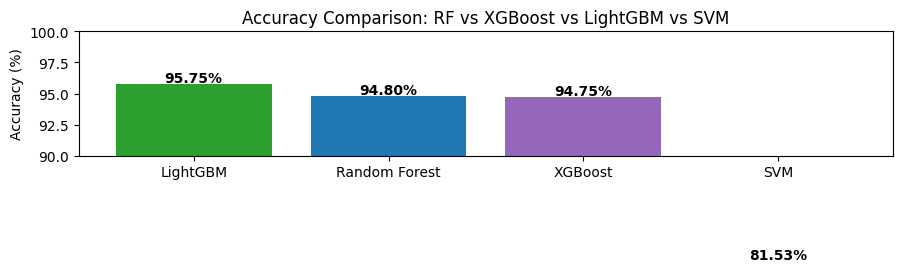


🏆 WINNING MODEL: LightGBM with 95.75% Accuracy!
Saved winning model and preprocessors to Google Drive successfully!


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# 1. Aggregate and rank all 4 model performances
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LightGBM', 'SVM'],
    'Accuracy (%)': [rf_acc * 100, xgb_acc * 100, lgbm_acc * 100, svm_acc * 100]
}).sort_values(by='Accuracy (%)', ascending=False)

print("==========================================")
print("      FINAL 4-MODEL COMPARISON SUMMARY    ")
print("==========================================")
print(comparison_df.to_string(index=False))

# 2. Plot performance comparison
plt.figure(figsize=(9, 5))
bars = plt.bar(comparison_df['Model'], comparison_df['Accuracy (%)'], color=['#2ca02c', '#1f77b4', '#9467bd', '#ff7f0e'])
plt.ylim(90, 100)
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison: RF vs XGBoost vs LightGBM vs SVM')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.15, f"{yval:.2f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Identify and save the winning model to Google Drive
best_model_name = comparison_df.iloc[0]['Model']
best_accuracy = comparison_df.iloc[0]['Accuracy (%)']

model_dict = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model,
    'SVM': svm_model
}

winning_model = model_dict[best_model_name]

model_save_path = f'/content/drive/MyDrive/best_malware_model_{best_model_name.replace(" ", "_").lower()}.pkl'
scaler_save_path = '/content/drive/MyDrive/malware_scaler.pkl'
encoder_save_path = '/content/drive/MyDrive/malware_label_encoder.pkl'

joblib.dump(winning_model, model_save_path)
joblib.dump(scaler, scaler_save_path)
joblib.dump(label_encoder, encoder_save_path)

print(f"\n🏆 WINNING MODEL: {best_model_name} with {best_accuracy:.2f}% Accuracy!")
print(f"Saved winning model and preprocessors to Google Drive successfully!")

In [34]:
import joblib

# 1. Define Drive paths for all artifacts
artifacts = {
    'malware_rf_model.pkl': rf_model,
    'malware_xgb_model.pkl': xgb_model,
    'malware_lgbm_model.pkl': lgbm_model,
    'malware_svm_model.pkl': svm_model,
    'malware_scaler.pkl': scaler,
    'malware_label_encoder.pkl': label_encoder
}

# 2. Export each file to Google Drive
print("--- Exporting All Models & Artifacts to Google Drive ---")
for filename, obj in artifacts.items():
    save_path = f'/content/drive/MyDrive/{filename}'
    joblib.dump(obj, save_path)
    print(f" Saved: {filename}")

print("\nAll 4 models, scaler, and label encoder are successfully stored in Google Drive!")

--- Exporting All Models & Artifacts to Google Drive ---
 Saved: malware_rf_model.pkl
 Saved: malware_xgb_model.pkl
 Saved: malware_lgbm_model.pkl
 Saved: malware_svm_model.pkl
 Saved: malware_scaler.pkl
 Saved: malware_label_encoder.pkl

All 4 models, scaler, and label encoder are successfully stored in Google Drive!


In [35]:
import json
from google.colab import files

sample_payload = {
    "sample_id": "CIC_MALDROID_SAMPLE_0482",
    "predicted_label": "Banking Malware",
    "top_contributing_features": [
        "android.permission.READ_SMS",
        "android.permission.SEND_SMS",
        "android.permission.RECEIVE_SMS",
        "android.permission.SYSTEM_ALERT_WINDOW",
        "Ljava/lang/reflect/Method;->invoke",
        "android.telephony.TelephonyManager;->getDeviceId",
        "android.content.Context;->registerReceiver"
    ]
}

with open("sample_prediction.json", "w") as f:
    json.dump(sample_payload, f, indent=4)

files.download("sample_prediction.json")
print("sample_prediction.json created and downloading!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

sample_prediction.json created and downloading!


In [36]:
from xgboost import XGBClassifier

# Initialize and train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)

# Predict & evaluate
xgb_preds = xgb_model.predict(X_test_scaled)
xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"XGBoost Training Complete!")
print(f"XGBoost Accuracy: {xgb_acc * 100:.2f}%")

XGBoost Training Complete!
XGBoost Accuracy: 94.75%


In [37]:
#Define the Inference Class
import joblib
import pandas as pd
import numpy as np
from google.colab import drive

class MalwareInferenceEngine:
    def __init__(self, model_filename='malware_rf_model.pkl'):
        """
        Loads pre-trained artifacts from Google Drive.
        """
        drive.mount('/content/drive', force_remount=False)

        base_path = '/content/drive/MyDrive/'

        print("Loading inference artifacts...")
        self.model = joblib.load(base_path + model_filename)
        self.scaler = joblib.load(base_path + 'malware_scaler.pkl')
        self.label_encoder = joblib.load(base_path + 'malware_label_encoder.pkl')
        print("Model, Scaler, and Label Encoder loaded successfully!")

    def predict(self, raw_features_df):
        """
        Scales raw features, predicts classes, and extracts confidence scores.
        """
        # 1. Standardize features using the saved scaler
        scaled_features = self.scaler.transform(raw_features_df)

        # 2. Get numerical predictions and probability distributions
        predictions = self.model.predict(scaled_features)
        probabilities = self.model.predict_proba(scaled_features)

        # 3. Decode numerical labels back to text categories
        predicted_labels = self.label_encoder.inverse_transform(predictions)

        # 4. Format detailed results
        results = []
        for idx, label in enumerate(predicted_labels):
            confidence = float(np.max(probabilities[idx])) * 100
            results.append({
                "predicted_class": label,
                "confidence_score": f"{confidence:.2f}%",
                "class_probabilities": {
                    cls: f"{prob * 100:.2f}%"
                    for cls, prob in zip(self.label_encoder.classes_, probabilities[idx])
                }
            })

        return results

In [38]:
# Initialize the engine
engine = MalwareInferenceEngine(model_filename='malware_rf_model.pkl')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading inference artifacts...
Model, Scaler, and Label Encoder loaded successfully!


In [39]:
#Run a Prediction to View Output
import json

# 1. Take 3 raw samples from your test dataset
sample_raw_features = pd.DataFrame(
    scaler.inverse_transform(X_test_scaled[:3]),
    columns=X_filtered.columns
)

# 2. Pass them to the inference engine
predictions = engine.predict(sample_raw_features)

# 3. Print clean JSON output
print(json.dumps(predictions, indent=4))

[
    {
        "predicted_class": "Banking",
        "confidence_score": "100.00%",
        "class_probabilities": {
            "Adware": "0.00%",
            "Banking": "100.00%",
            "Benign": "0.00%",
            "Riskware": "0.00%",
            "SMS Malware": "0.00%"
        }
    },
    {
        "predicted_class": "Adware",
        "confidence_score": "79.00%",
        "class_probabilities": {
            "Adware": "79.00%",
            "Banking": "4.00%",
            "Benign": "6.00%",
            "Riskware": "9.00%",
            "SMS Malware": "2.00%"
        }
    },
    {
        "predicted_class": "SMS Malware",
        "confidence_score": "100.00%",
        "class_probabilities": {
            "Adware": "0.00%",
            "Banking": "0.00%",
            "Benign": "0.00%",
            "Riskware": "0.00%",
            "SMS Malware": "100.00%"
        }
    }
]


In [40]:
#Structuring Outputs for Agentic AI Integration
def analyze_apk_features_tool(raw_features_dict: dict) -> dict:
    """
    Agent Tool Function: Takes a feature dictionary for an Android sample,
    aligns it to the model's 317 features, and returns an automated verdict.
    """
    # 1. Convert input dictionary into a DataFrame row
    input_df = pd.DataFrame([raw_features_dict])

    # 2. Reindex to guarantee all 317 expected features are present (fill missing features with 0.0)
    input_df = input_df.reindex(columns=X_filtered.columns, fill_value=0.0)

    # 3. Run prediction via the inference engine
    analysis_result = engine.predict(input_df)[0]

    # 4. Return structured verdict for LLM consumption
    return {
        "status": "SUCCESS",
        "verdict": analysis_result["predicted_class"],
        "confidence": analysis_result["confidence_score"],
        "probabilities": analysis_result["class_probabilities"]
    }

# Quick validation test with sample 0
sample_dict = sample_raw_features.iloc[0].to_dict()
tool_output = analyze_apk_features_tool(sample_dict)

print("Agent Tool Test Output:")
print(tool_output)

Agent Tool Test Output:
{'status': 'SUCCESS', 'verdict': 'Banking', 'confidence': '100.00%', 'probabilities': {'Adware': '0.00%', 'Banking': '100.00%', 'Benign': '0.00%', 'Riskware': '0.00%', 'SMS Malware': '0.00%'}}
